# Algorithm Analysis Tool

## Prerequisites

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle
import pandas as pd
import networkx as nx
from deap import gp
import logging
import random

import nest_asyncio
from discrete_optimization.datasets import fetch_data_from_psplib

# Main module for RCPSP Model
from discrete_optimization.rcpsp.rcpsp_model import RCPSPSolution
from discrete_optimization.rcpsp.rcpsp_parser import get_data_available, parse_file
from discrete_optimization.rcpsp.rcpsp_utils import (
    Graph,
    compute_graph_rcpsp,
    plot_ressource_view,
    plot_task_gantt,
)

# patch asyncio so that applications using async functions can run in jupyter
nest_asyncio.apply()

# set logging level
logging.basicConfig(level=logging.INFO)

# GP Tree Visualization

In [8]:
def add(left, right):
    def lazy_add():
        return left() + right()

    return lazy_add


def sub(left, right):
    def lazy_sub():
        return left() - right()

    return lazy_sub


def mul(left, right):
    def lazy_mul():
        return left() * right()

    return lazy_mul


def protectedDiv(left, right):
    def lazy_protected_Div():
        try:
            return left() / right()
        except ZeroDivisionError:
            return 1

    return lazy_protected_Div
from simulation import Serial_SGS_Builder
simulation = Serial_SGS_Builder()  # serial or parallel SGS
# loading the primitive set
# Primitives
pset = gp.PrimitiveSet("MAIN", 0)
pset.addPrimitive(add, 2)
pset.addPrimitive(sub, 2)
pset.addPrimitive(mul, 2)
pset.addPrimitive(protectedDiv, 2)
# Terminals
pset.addTerminal(simulation.ES)
pset.addTerminal(simulation.EF)
pset.addTerminal(simulation.LS)
pset.addTerminal(simulation.LF)
pset.addTerminal(simulation.SPT)
pset.addTerminal(simulation.TPC)
pset.addTerminal(simulation.TSC)
pset.addTerminal(simulation.MIS)
pset.addTerminal(simulation.RR)
pset.addTerminal(simulation.AVG_R_REQ)
pset.addTerminal(simulation.MAX_R_REQ)
pset.addTerminal(simulation.MIN_R_REQ)
pset.addTerminal(simulation.GRPW)
pset.addTerminal(simulation.GRD)
pset

In [16]:
# Load a GP tree from string
gp_tree = gp.PrimitiveTree.from_string("add(LS,ES)", pset)


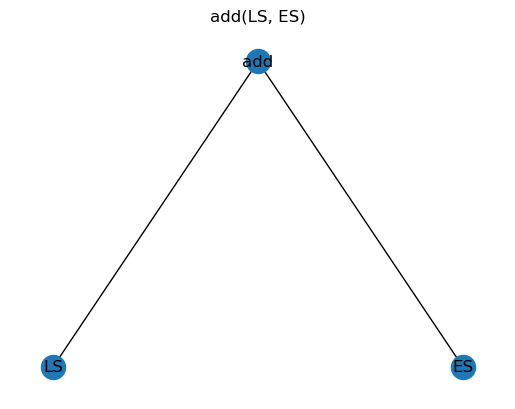

In [17]:
# Plot the GP tree
utils.plot_tree(gp_tree)

# Popluation Analysis

### Load fitness log

In [16]:
fitness_log = pd.read_csv("./standardgp_500_25_archive.csv")
fitness_log

fsgpfitness_log = pd.read_csv("./fsgp_500_25_archive.csv")
fsgpfitness_log

,gen,fitness,validation_fitness
0,0,66.937500,NaN
1,0,65.579167,NaN
2,0,67.312500,NaN
3,0,71.312500,NaN
4,0,67.775000,NaN
...,...,...,...
12995,25,61.927083,NaN
12996,25,62.035417,NaN
12997,25,61.914583,NaN
12998,25,61.910417,NaN


### Convergence Curve

<AxesSubplot:xlabel='gen', ylabel='fitness'>

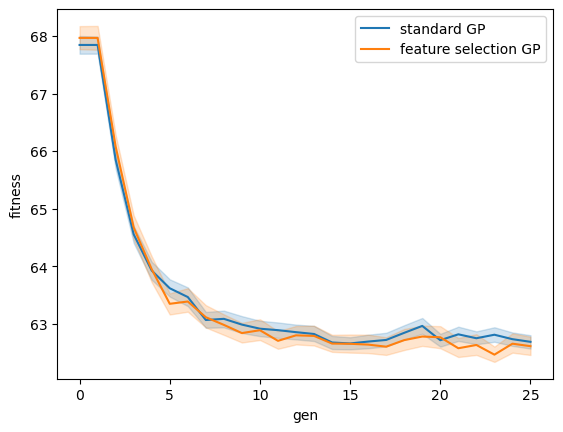

In [19]:
%matplotlib inline
ax=sns.lineplot(data=fitness_log, x="gen", y="fitness",label="standard GP")
sns.lineplot(data=fsgpfitness_log, x="gen",y="fitness", label="feature selection GP")
# ax.legend("on")

### Population Distributions

Fitness distribution

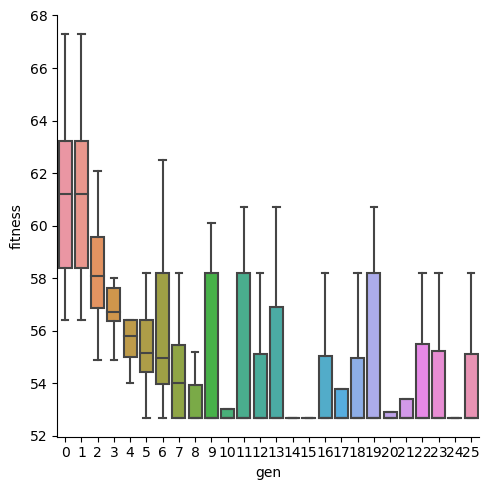

In [37]:
%matplotlib inline
# sns.catplot(x="gen", y="fitness", data=fitness_log)
# sns.catplot(data=fitness_log, x="gen", y="fitness", kind="swarm")
# sns.catplot(data=fitness_log, x="gen", y="fitness", kind="violin")
sns.catplot(data=fitness_log, x="gen", y="fitness",
            kind="box", showfliers=False)


Validation Fitness distribution 

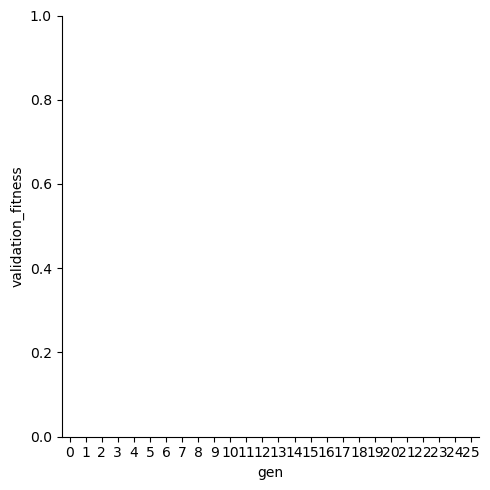

In [38]:
%matplotlib inline
# sns.catplot(x="gen", y="fitness", data=df)
# sns.catplot(data=df, x="gen", y="fitness", kind="swarm")
# sns.catplot(data=df, x="gen", y="fitness", kind="violin")
sns.catplot(data=fitness_log, x="gen", y="validation_fitness",
            kind="box", showfliers=False)


Fitness and Validation Fitness Comparisons

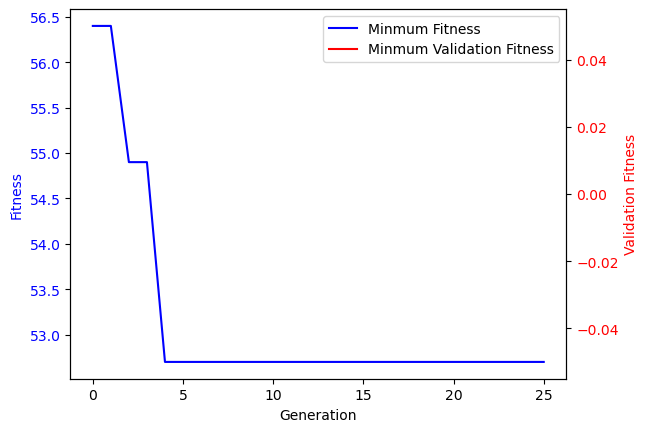

In [39]:
fig, ax1 = plt.subplots()
fitness_min = fitness_log.groupby("gen").min()
# fitness_min["fitness"]
line1 = ax1.plot(fitness_min["fitness"], "b-", label="Minmum Fitness")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness", color="b")
for tl in ax1.get_yticklabels():
    tl.set_color("b")

ax2 = ax1.twinx()
line2 = ax2.plot(fitness_min["validation_fitness"],
                 "r-", label="Minmum Validation Fitness")
ax2.set_ylabel("Validation Fitness", color="r")
for tl in ax2.get_yticklabels():
    tl.set_color("r")

lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc="upper right")

plt.show()


# Feature Analysis

### Load feature log

In [32]:
terminal_counts_all = pd.read_csv("./fsgp_500_25_terminal_count_all.csv")
terminal_counts_all

terminal_counts_elites = pd.read_csv("./fsgp_500_25_terminal_count_elites.csv")
terminal_counts_elites

,gen,terminal,occurrences
0,0,ES,6
1,0,EF,6
2,0,LS,10
3,0,LF,5
4,0,SPT,3
...,...,...,...
359,25,AVG_R_REQ,25
360,25,MAX_R_REQ,12
361,25,MIN_R_REQ,0
362,25,GRPW,0


## Lineplot

In [6]:
terminal_counts_tr = pd.read_csv("./fsgp_all.csv")
terminal_counts_tr

,gen,terminal,occurrences
0,0,ES,11
1,0,EF,9
2,0,LS,6
3,0,LF,4
4,0,SPT,13
...,...,...,...
359,25,AVG_R_REQ,0
360,25,MAX_R_REQ,0
361,25,MIN_R_REQ,0
362,25,GRPW,28


In [34]:
from plotly.offline import init_notebook_mode, iplot
from plotly.graph_objs import *
import plotly.express as px
px.line(terminal_counts_all, x="gen", y="occurrences", color="terminal")

In [35]:
from plotly.offline import init_notebook_mode, iplot
from plotly.graph_objs import *
import plotly.express as px
px.line(terminal_counts_elites, x="gen", y="occurrences", color="terminal")


<AxesSubplot:xlabel='gen', ylabel='occurrances'>

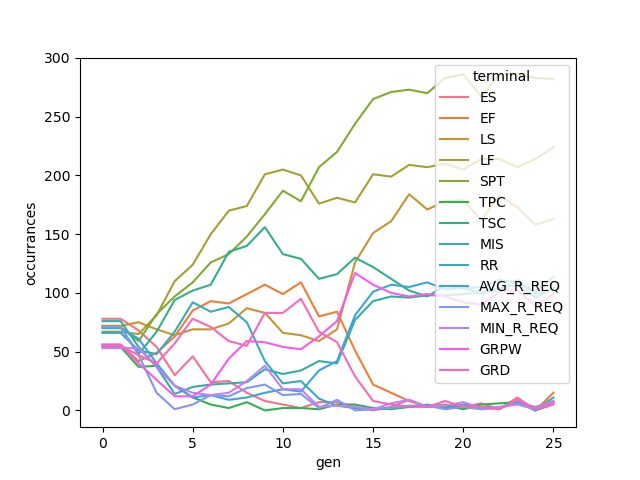

In [ ]:
# Activiate interactive mode
%matplotlib widget
sns.lineplot(data=terminal_counts, x="gen", y="occurrences", hue="terminal")

## Heatmap
Use heatmap to see the terminal occurrance distribution
Arguments description:
`annot`: True, show the number in each cell. 
For more information:
https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap

<AxesSubplot:xlabel='gen', ylabel='terminal'>

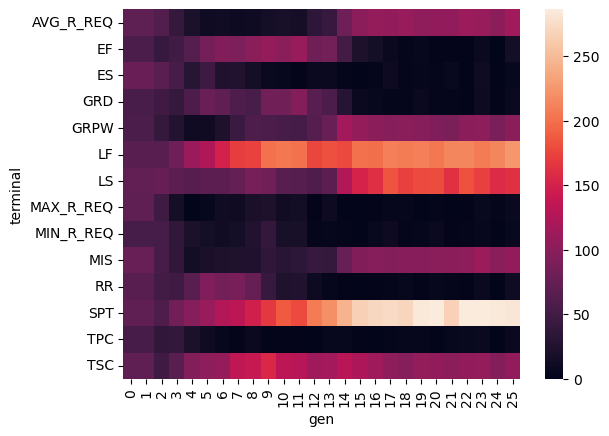

In [22]:
counts = terminal_counts.pivot("terminal", "gen", "occurrances")
sns.heatmap(counts, annot=False, fmt="d", xticklabels="auto")


## 3D Bar chart

In [23]:
# Activiate interactive mode
%matplotlib widget


def plot_terminal_occurrance_3D(data: pd.DataFrame):
    """
    Plot 3D bar chart to show the terminal counts over generation
    X axis: Terminal
    Y axis: Generation
    Z axis: Counts
    """
    from mpl_toolkits.mplot3d import Axes3D
    dz = data["occurrances"]  # counts (generations * terminals)

    x_labels = data["terminal"].unique().tolist()  # terminals
    y_labels = data["gen"].unique().tolist()  # generations

    num_gens = len(y_labels)
    num_terminals = len(x_labels)
    x_gap = 1
    y_gap = 1

    xs = list(range(num_terminals)) * num_gens # 
    ys = data["gen"].tolist()
    zs = [0] * num_gens * num_terminals

    # colormap
    colors_from_color_map = mpl.cm.get_cmap("tab20").colors
    colors = []
    alphas = np.linspace(0.1, 1, num_gens, endpoint=True).tolist()
    for alpha in alphas:
        for i in range(num_terminals):
            colors.append(mpl.colors.to_rgba(
                colors_from_color_map[i], alpha))
    fig, ax = plt.subplots()
    ax = Axes3D(fig)
    ax.bar3d(xs, ys, zs, dx=0.5, dy=0.5, dz=dz, color=colors)
    ax.set_xticks(list(range(num_terminals)), x_labels)
    ax.set_yticks(list(range(num_gens)), y_labels)
    ax.set_xlabel("terminal")
    ax.set_ylabel("generation")
    ax.set_zlabel("count")

    plt.show()


C:\Users\YuanTian\AppData\Local\Temp\ipykernel_14404\2811657459.py:36: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


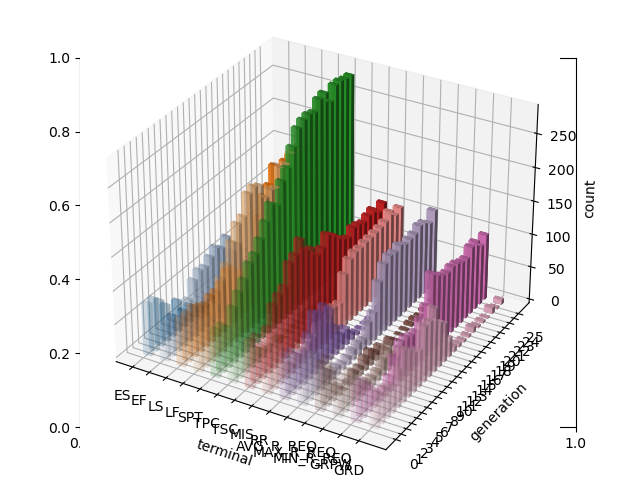

In [24]:
plot_terminal_occurrance_3D(terminal_counts)

# Problem Visulization

## Project Precedence Relations

In [ ]:
%matplotlib widget
# compute graph
graph: Graph = compute_graph_rcpsp(rcpsp_model)
graph_nx = graph.to_networkx()
# compute positions
dfs = nx.dfs_tree(G=graph_nx, source=1, depth_limit=10)
shortest_path_length = nx.shortest_path_length(dfs, 1)
length_to_nodes = {}
position = {}
for node in sorted(shortest_path_length, key=lambda x: shortest_path_length[x]):
    length = shortest_path_length[node]
    while not (length not in length_to_nodes or len(length_to_nodes[length]) <= 5):
        length += 1
    if length not in length_to_nodes:
        length_to_nodes[length] = []
    length_to_nodes[length] += [node]
    position[node] = (length, len(length_to_nodes[length]))

# different color for source and sink task
sink_source_color = "#FFB000"
normal_task_color = "#648FFF"
node_color = len(graph_nx) * [normal_task_color]
node_color[0] = sink_source_color
node_color[-1] = sink_source_color

# plot
nx.draw_networkx(graph_nx, pos=position, node_color=node_color)
plt.show()

## Project Solution

# Algorithms Comparison

## Significance Test